# **Set up Environment**

In [ ]:
## Load data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

%pip install xgboost # im sorry
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, classification_report
from collections import Counter
import numpy as np
from tqdm.auto import tqdm
import os

directory = "MINDsmall_train/"
shortened_directory = "MINDsmall_train_shortened_data/"

if os.path.exists(directory):
    active_directory = directory
elif os.path.exists(shortened_directory):
    active_directory = shortened_directory
else:
    raise FileNotFoundError(f"Neither '{directory}' nor '{shortened_directory}' found.")

behaviour_columns  = ["impression_id", "user_id", "time", "history", "impressions"]
news_columns = ["news_id", "category", "subcategory", "title",
             "abstract", "url", "title_entities", "abstract_entities"]

behaviour_df  = pd.read_table(f"{active_directory}/behaviors.tsv", header=None, names=behaviour_columns)
news_df = pd.read_table(f"{active_directory}/news.tsv",      header=None, names=news_columns)
mind_entity_embedding = os.path.join(active_directory, "entity_embedding.vec")
mind_relation_embedding = os.path.join(active_directory, "relation_embedding.vec")

Note: you may need to restart the kernel to use updated packages.


# **Pre-processing the data**

## **Datasets**

In [161]:
display(behaviour_df.head(3))

,impression_id,user_id,time,history,impressions
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...
2,3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...


Reducing the number of rows in `behaviour_df`:

In [ ]:
THRESHOLD = 150

behaviour_df['impression_count'] = behaviour_df['impressions'].apply(lambda x: len(str(x).split()))

num_users_over = behaviour_df[behaviour_df['impression_count'] >= THRESHOLD]['user_id'].nunique()
print(f"Users with more than {THRESHOLD} impressions: {num_users_over}")

behaviour_df = behaviour_df[behaviour_df['impression_count'] >= THRESHOLD]
print(f"Shape of behaviour_df after filtering: {behaviour_df.shape}")
print(f"Total users remaining: {behaviour_df['user_id'].nunique()}")

Users with more than 150 impressions: 1869
Shape of behaviour_df after filtering: (2449, 6)
Total users remaining: 1962


In [163]:
print("\n--- News DataFrame ---")
display(news_df.head(3))
print(f'Shape of news_df: {news_df.shape}')


--- News DataFrame ---


,news_id,category,subcategory,title,abstract,url,title_entities,abstract_entities
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[]
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik..."
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId..."


Shape of news_df: (51282, 8)


## **Join them and flatten**

In [ ]:
## Build the event stream
def build_event_stream(behaviour_df: pd.DataFrame, news_df: pd.DataFrame) -> pd.DataFrame:

    news_indexed = news_df.set_index("news_id")

    behaviour_df = behaviour_df.copy()
    behaviour_df["time"]    = pd.to_datetime(behaviour_df["time"], format="%m/%d/%Y %I:%M:%S %p")
    behaviour_df["history"] = behaviour_df["history"].fillna("").str.split()

    rows = []
    for _, row in behaviour_df.iterrows():

        if pd.isna(row["impressions"]):
            continue

        pairs = []
        for item in row["impressions"].split():
            nid, label = item.rsplit("-", 1)
            if nid in news_indexed.index:
                pairs.append((nid, int(label)))

        if not pairs:
            continue

        candidate_ids = [nid for nid, _ in pairs]
        candidate_cats    = [news_indexed.loc[nid, "category"]    for nid in candidate_ids]
        candidate_subcats = [news_indexed.loc[nid, "subcategory"] for nid in candidate_ids]
        propensity        = 1.0 / len(candidate_ids)

        for nid, clicked in pairs:
            rows.append({
                "impression_id": row["impression_id"],
                "user_id": row["user_id"],
                "time": row["time"],
                "history": row["history"],

                #impression-level information
                "candidates": candidate_ids,
                "candidate_categories": candidate_cats,
                "candidate_subcategories": candidate_subcats,
                "propensity": propensity,

                #article-level information
                "article_shown": nid,
                "clicked": clicked,
                "category_shown": news_indexed.loc[nid, "category"],
                "subcategory_shown": news_indexed.loc[nid, "subcategory"],
            })
    return pd.DataFrame(rows)

events_df = build_event_stream(behaviour_df, news_df)
events_df.head(3)


,impression_id,user_id,time,history,candidates,candidate_categories,candidate_subcategories,propensity,article_shown,clicked,category_shown,subcategory_shown
0,7,U8355,2019-11-11 12:22:09,"[N8419, N15771, N1431, N5888, N18663, N24123, ...","[N51346, N33848, N15132, N10688, N6342, N61359...","[sports, sports, news, news, health, sports, n...","[football_nfl, football_nfl_videos, newsworld,...",0.00578,N51346,0,sports,football_nfl
1,7,U8355,2019-11-11 12:22:09,"[N8419, N15771, N1431, N5888, N18663, N24123, ...","[N51346, N33848, N15132, N10688, N6342, N61359...","[sports, sports, news, news, health, sports, n...","[football_nfl, football_nfl_videos, newsworld,...",0.00578,N33848,0,sports,football_nfl_videos
2,7,U8355,2019-11-11 12:22:09,"[N8419, N15771, N1431, N5888, N18663, N24123, ...","[N51346, N33848, N15132, N10688, N6342, N61359...","[sports, sports, news, news, health, sports, n...","[football_nfl, football_nfl_videos, newsworld,...",0.00578,N15132,0,news,newsworld


---
# **Checkpoint 1**

There are a lot of overlapping terms used interchangeably in different sources which can be confusing and Im still not sure what is correct or wrong. So I defined a set of terms below which I will align with so you know what I am referring to.

**High Level overview:**

We want to build a MAB algorithm, to recommend different news items that will improve the reward (whether the user clicks or not). For example, User #1 was recommended Sports by Microsoft, but our MAB thinks that Music is better.

However, since we are dealing with historical data, we have no idea of whether User #1 will click Music or not. Therefore, we need to create a model to simulate whether the user will click Music or not. The probability will be estimated with a linear model, and the probability will be converted to the *reward* using *Bernoulli Distribution*.

We will also need to score our prediciton against a synthetic *truth*. We build this synthetic *true expected reward* using a logistic regression model, using the user's context features.

**The arms:**

There are 51,282 unique news articles, and it is not practical to build a MAB with so many arms. Instead, we shall use the categories as arms: the probability model will be trained on the categories, and the MAB will also recommend and estimate reward based on the categories rather than the individual news items. This reduces the number of arms to 16.
(INCLUDE AS LIMITATION)

**Reducing number of rows:**

We reduce the number of rows for two reasons:
- Way too long to run
- Cold start problem: When the MAB initialises at the start, if a user has fewer than 16 candidates, it will jump to a new user before the MAB finishes intialising all arms which can confuse the algorithm.

Instead of just randomly sampling the data to reduce the number of data points, a smarter way will be to choose individuals with more than a certain number of candidates (150 in this case). This gives a more stable foundation for the MAB to learn and also reduces the dataset to about 500k rows from initial 6 million. However, it definitely is biased because we are dodging the cold start problem that real world will face (INCLUDE AS LIMITATION)

**Datasets:**

Currently we have the `events_df`, the flattened master dataset in which every subsequent dataset will be built off of. Next we will build `featured_df` (with engineered features) and `train_dm` (contains only the features we use to train the NN reward model).

---
**Definitions:**
- **Reward**: Clicked or no click (1 or 0)

- **Reward model**: Bernoulli Distribution (converts the estimated reward to a 1 or 0). This works like a weighted coin flip, lets say the estimated reward is 0.8, then they will randomly sample between 0 and 1, and if its above 0.8 then its converted to 1.

===========================================================

- **Estimated Reward**: The estimated probability of each arm assigned by the MAB internal mechanisms, which updates with every pull (E.g. Sports = 0.45, Music = 0.9)

- **True Expected Reward**: The "true" probability assigned to each arm. (E.g. Sports = 0.6, Music = 0.3..) estimated by our model (Logistic Regression)

- **Regret**: The regret of each pull is therefore the True *Expected Reward - Expected Reward of the chosen arm*

- For example for the situation above: The MAB chooses music because it has the highest estimated reward. However, the "true" probability of Music is only 0.3 but the best arm is actually Sports with 0.6. Hence, the regret is 0.6 - 0.3 = 0.3.


## **Feature Engineering**
How we generated `sematic_similarity_category`:

=============================================================

To create the semantic_similarity_category feature, you engineered mathematical profiles for both your news categories and your users, and then measured the distance between them. First, you built a "category profile" by gathering all the Wikidata QIDs from every article within a specific category and flat-averaging their 100-dimensional Knowledge Graph (KG) embeddings. This generated two representative vectors for each category, capturing its general title and abstract themes. Next, you constructed a corresponding "user profile" by applying the exact same flat-averaging process to the QIDs of the articles in a user's historical reading list, yielding two vectors that represent their individual reading preferences.

To generate the final feature, your code iterated through every row in the dataset and calculated the cosine similarity between the user's history vectors and the category vectors for the specific arm shown. You calculated the similarity for the titles, calculated it for the abstracts, and then averaged those two scores together into a single scalar number. As you noted in your comments, aggregating this data up to the category level is a crucial engineering step for offline Multi-Armed Bandits because it solves the counterfactual problem. Instead of tying the similarity to a specific article, this method makes the feature completely arm-swappable, allowing your offline simulator to effortlessly test alternative category arms on a user by simply swapping in a different category vector and recalculating the distance.

===========================================================

Honestly not too sure how they generated this, but END STATE what we have is for every row, a number to represent how similar the category shown is to the user's history.

---
# **Feature Engineering:**
Before training our models, we need to engineer some features first.

The four features we chose to use are:
- `semantic_similarity_category`: Measures how conceptually similar the category of the suggested article is to the user's past reading interests.
- `history_length`: tracks the number of news that the user clicked previously
- `cat_match_ratio`: Broad interest match between category of historical clicks and current suggested article
- `category_shown`: The category of the suggested article (already in original df)



This features will be built into a dataframe called `featured_df`.

In [165]:
## EVENTS DF IS LARGE. FIRST DROP THE COLUMNS WE DONT USE FOR ENGINEERING
events_df = events_df.drop(columns=['user_id', 'candidates', 'candidate_categories', 'candidate_subcategories', 'propensity'])

## **Raw Events EDA (`events_df`)**
Visualising the raw event stream before feature engineering.

In [ ]:
def load_vec(path: str) -> dict:
    """Load a tab-separated .vec file into {id: np.ndarray}."""
    id2vec = {}
    with open(path) as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) > 1:
                id2vec[parts[0]] = np.array(parts[1:], dtype=np.float32)
    return id2vec

# entity2vec   = load_vec("entity_embedding.vec")   # QID  → 100-dim
# relation2vec = load_vec("relation_embedding.vec")  # PID  → 100-dim  (available for future use)

entity2vec   = load_vec(mind_entity_embedding)
relation2vec = load_vec(mind_relation_embedding)

KG_DIM = len(next(iter(entity2vec.values())))      # = 100
print(f"Entity embeddings loaded:   {len(entity2vec):,}  (dim={KG_DIM})")
print(f"Relation embeddings loaded: {len(relation2vec):,}")

Entity embeddings loaded:   26,904  (dim=100)
Relation embeddings loaded: 1,091


In [ ]:
import json

def extract_qids(entity_str):
    """Safely extract Wikidata QIDs from JSON strings."""
    try:
        if pd.isna(entity_str): return []
        entities = json.loads(entity_str)
        return [e["WikidataId"] for e in entities if "WikidataId" in e]
    except (json.JSONDecodeError, TypeError):
        return []

def mean_kg_vec(qids: list, entity2vec: dict, dim: int) -> np.ndarray:
    """Average the KG vectors for a list of QIDs."""
    vecs = [entity2vec[q] for q in qids if q in entity2vec]
    return np.mean(vecs, axis=0).astype(np.float32) if vecs else np.zeros(dim, dtype=np.float32)

# entity2vec = load_vec("entity_embedding.vec")
KG_DIM = 100

print("Pre-extracting QIDs from news_df...")
article_title_qids = {}
article_abstract_qids = {}

for _, row in news_df.iterrows():
    nid = row["news_id"]
    article_title_qids[nid] = extract_qids(row.get("title_entities", ""))
    article_abstract_qids[nid] = extract_qids(row.get("abstract_entities", ""))

#we still want the mean vectors for the candidate articles for Step 4
article_title_kg_vec = {nid: mean_kg_vec(qids, entity2vec, KG_DIM) for nid, qids in article_title_qids.items()}
article_abstract_kg_vec = {nid: mean_kg_vec(qids, entity2vec, KG_DIM) for nid, qids in article_abstract_qids.items()}


print("Pre-computing impression (history) vectors using flat averaging...")
impression_meta = events_df.drop_duplicates("impression_id")[["impression_id", "history"]]

history_title_kg_vec = {}
history_abstract_kg_vec = {}

for _, row in impression_meta.iterrows():
    imp_id = row["impression_id"]
    hist_ids = row["history"]

    if not hist_ids:
        history_title_kg_vec[imp_id] = np.zeros(KG_DIM, dtype=np.float32)
        history_abstract_kg_vec[imp_id] = np.zeros(KG_DIM, dtype=np.float32)
        continue

    #pool ALL QIDs from historical articles into one giant flat list
    flat_title_qids = []
    flat_abstract_qids = []
    for hid in hist_ids:
        flat_title_qids.extend(article_title_qids.get(hid, []))
        flat_abstract_qids.extend(article_abstract_qids.get(hid, []))

    #calculate the mean ONCE on the giant flat list
    history_title_kg_vec[imp_id] = mean_kg_vec(flat_title_qids, entity2vec, KG_DIM)
    history_abstract_kg_vec[imp_id] = mean_kg_vec(flat_abstract_qids, entity2vec, KG_DIM)

print("History vectors computed!")

def batch_cosine_kg_chunked(article_lookup: dict, history_lookup: dict,
                            article_ids: np.ndarray, impression_ids: np.ndarray,
                            batch_size=50000) -> np.ndarray:

    n_samples = len(article_ids)
    results = np.zeros(n_samples, dtype=np.float32)

    #porocess the math in bite-sized chunks
    for start_idx in range(0, n_samples, batch_size):
        end_idx = min(start_idx + batch_size, n_samples)

        art_chunk = article_ids[start_idx:end_idx]
        imp_chunk = impression_ids[start_idx:end_idx]

        A = np.vstack([article_lookup.get(nid, np.zeros(KG_DIM, dtype=np.float32)) for nid in art_chunk])
        H = np.vstack([history_lookup[imp] for imp in imp_chunk])

        A_norm = A / np.linalg.norm(A, axis=1, keepdims=True).clip(min=1e-9)
        H_norm = H / np.linalg.norm(H, axis=1, keepdims=True).clip(min=1e-9)

        results[start_idx:end_idx] = (A_norm * H_norm).sum(axis=1)

    return results

article_ids = events_df["article_shown"].to_numpy()
impression_ids = events_df["impression_id"].to_numpy()

events_df["semantic_similarity_title_entities"] = batch_cosine_kg_chunked(
    article_title_kg_vec, history_title_kg_vec, article_ids, impression_ids
)
events_df["semantic_similarity_abstract_entities"] = batch_cosine_kg_chunked(
    article_abstract_kg_vec, history_abstract_kg_vec, article_ids, impression_ids
)

Pre-extracting QIDs from news_df...
Pre-computing impression (history) vectors using flat averaging...
History vectors computed!


In [ ]:
#instead of comparing the specific article's entities to history,
# we compare the CATEGORY's representative entity vector to the user's history.
#this means the feature is recomputable for ANY arm -fixing the counterfactual problem.

import time

print("Building category-level KG vectors...")

cat_dict       = dict(zip(news_df['news_id'], news_df['category']))
all_categories = sorted(news_df['category'].dropna().unique().tolist())

#for each category, pool ALL QIDs from ALL articles in that category
# then take the mean -> one 100-dim vector per category
category_title_kg_vec    = {}
category_abstract_kg_vec = {}

for cat in all_categories:
    cat_news_ids = news_df[news_df['category'] == cat]['news_id'].tolist()

    flat_title_qids    = []
    flat_abstract_qids = []
    for nid in cat_news_ids:
        flat_title_qids.extend(article_title_qids.get(nid, []))
        flat_abstract_qids.extend(article_abstract_qids.get(nid, []))

    category_title_kg_vec[cat]    = mean_kg_vec(flat_title_qids,    entity2vec, KG_DIM)
    category_abstract_kg_vec[cat] = mean_kg_vec(flat_abstract_qids, entity2vec, KG_DIM)

print(f"Built vectors for {len(all_categories)} categories: {all_categories}")

# history_title_kg_vec and history_abstract_kg_vec are already built above —
# no need to recompute them.

#for each row: cosine_sim(history_vector, category_vector_of_shown_category)
#this is now arm-swappable: just change category_shown to any arm and recompute.

print("Computing semantic_similarity_category...")
start_time = time.time()

def build_featured_df(events_df, news_df, cat_dict, all_categories,
                      category_title_kg_vec, category_abstract_kg_vec,
                      history_title_kg_vec, history_abstract_kg_vec):

    df = events_df.copy()

    df["history_length"] = df["history"].apply(len)

    def calculate_cat_ratio(row):
        history = row["history"]
        if not history:
            return 0.0
        hist_cats = [cat_dict.get(nid) for nid in history if nid in cat_dict]
        if not hist_cats:
            return 0.0
        return hist_cats.count(row["category_shown"]) / len(hist_cats)

    df["cat_match_ratio"] = df.apply(calculate_cat_ratio, axis=1)

    #One column per category: fraction of user history that is that category.
    #when oracle swaps arm, just read hist_pct_{arm} — no recomputation needed.
    def get_hist_pcts(row):
        history = row["history"]
        if not history:
            return {f'hist_pct_{c}': 0.0 for c in all_categories}
        hist_cats = [cat_dict.get(nid) for nid in history if nid in cat_dict]
        total = len(hist_cats)
        if total == 0:
            return {f'hist_pct_{c}': 0.0 for c in all_categories}
        return {f'hist_pct_{c}': hist_cats.count(c) / total for c in all_categories}

    print("  Computing hist_pct columns...")
    hist_pct_df = pd.DataFrame(
        df.apply(get_hist_pcts, axis=1).tolist(),
        index=df.index
    )
    df = pd.concat([df, hist_pct_df], axis=1)

    #cosine_sim(user history vector, category representative vector)
    #averaged across title + abstract for a single clean score.
    print("  Computing semantic_similarity_category...")

    imp_ids  = df["impression_id"].to_numpy()
    cat_shown = df["category_shown"].to_numpy()
    n = len(df)

    scores = np.zeros(n, dtype=np.float32)

    for i in range(n):
        imp_id = imp_ids[i]
        cat    = cat_shown[i]

        h_title    = history_title_kg_vec.get(imp_id,    np.zeros(KG_DIM, dtype=np.float32))
        h_abstract = history_abstract_kg_vec.get(imp_id, np.zeros(KG_DIM, dtype=np.float32))
        c_title    = category_title_kg_vec.get(cat,      np.zeros(KG_DIM, dtype=np.float32))
        c_abstract = category_abstract_kg_vec.get(cat,   np.zeros(KG_DIM, dtype=np.float32))

        def cosine(a, b):
            denom = np.linalg.norm(a) * np.linalg.norm(b)
            return float(np.dot(a, b) / denom) if denom > 1e-9 else 0.0

        scores[i] = (cosine(h_title, c_title) + cosine(h_abstract, c_abstract)) / 2.0

    df["semantic_similarity_category"] = scores

    return df

featured_df = build_featured_df(
    events_df, news_df, cat_dict, all_categories,
    category_title_kg_vec, category_abstract_kg_vec,
    history_title_kg_vec, history_abstract_kg_vec
)

minutes = (time.time() - start_time) / 60
print(f"Finished in {minutes:.2f} minutes.")
print(f"featured_df shape: {featured_df.shape}")
print(f"Columns: {list(featured_df.columns)}")

Building category-level KG vectors...
Built vectors for 17 categories: ['autos', 'entertainment', 'finance', 'foodanddrink', 'health', 'kids', 'lifestyle', 'middleeast', 'movies', 'music', 'news', 'northamerica', 'sports', 'travel', 'tv', 'video', 'weather']
Computing semantic_similarity_category...
  Computing hist_pct columns...
  Computing semantic_similarity_category...
Finished in 0.14 minutes.
featured_df shape: (469816, 29)
Columns: ['impression_id', 'time', 'history', 'article_shown', 'clicked', 'category_shown', 'subcategory_shown', 'semantic_similarity_title_entities', 'semantic_similarity_abstract_entities', 'history_length', 'cat_match_ratio', 'hist_pct_autos', 'hist_pct_entertainment', 'hist_pct_finance', 'hist_pct_foodanddrink', 'hist_pct_health', 'hist_pct_kids', 'hist_pct_lifestyle', 'hist_pct_middleeast', 'hist_pct_movies', 'hist_pct_music', 'hist_pct_news', 'hist_pct_northamerica', 'hist_pct_sports', 'hist_pct_travel', 'hist_pct_tv', 'hist_pct_video', 'hist_pct_weathe

In [169]:
events_df

,impression_id,time,history,article_shown,clicked,category_shown,subcategory_shown,semantic_similarity_title_entities,semantic_similarity_abstract_entities
0,7,2019-11-11 12:22:09,"[N8419, N15771, N1431, N5888, N18663, N24123, ...",N51346,0,sports,football_nfl,0.484891,0.569189
1,7,2019-11-11 12:22:09,"[N8419, N15771, N1431, N5888, N18663, N24123, ...",N33848,0,sports,football_nfl_videos,0.000000,0.258095
2,7,2019-11-11 12:22:09,"[N8419, N15771, N1431, N5888, N18663, N24123, ...",N15132,0,news,newsworld,0.641133,0.754591
3,7,2019-11-11 12:22:09,"[N8419, N15771, N1431, N5888, N18663, N24123, ...",N10688,0,news,newspolitics,0.625844,0.455345
4,7,2019-11-11 12:22:09,"[N8419, N15771, N1431, N5888, N18663, N24123, ...",N6342,0,health,weightloss,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...
469811,156876,2019-11-14 08:26:03,"[N13361, N4705, N30531, N9836, N41449]",N61296,0,news,newsus,0.181460,0.070173
469812,156876,2019-11-14 08:26:03,"[N13361, N4705, N30531, N9836, N41449]",N25165,0,news,newsworld,-0.125417,-0.109565
469813,156876,2019-11-14 08:26:03,"[N13361, N4705, N30531, N9836, N41449]",N17482,0,health,wellness,0.000000,0.000000
469814,156876,2019-11-14 08:26:03,"[N13361, N4705, N30531, N9836, N41449]",N12606,0,news,newspolitics,0.199718,0.000000


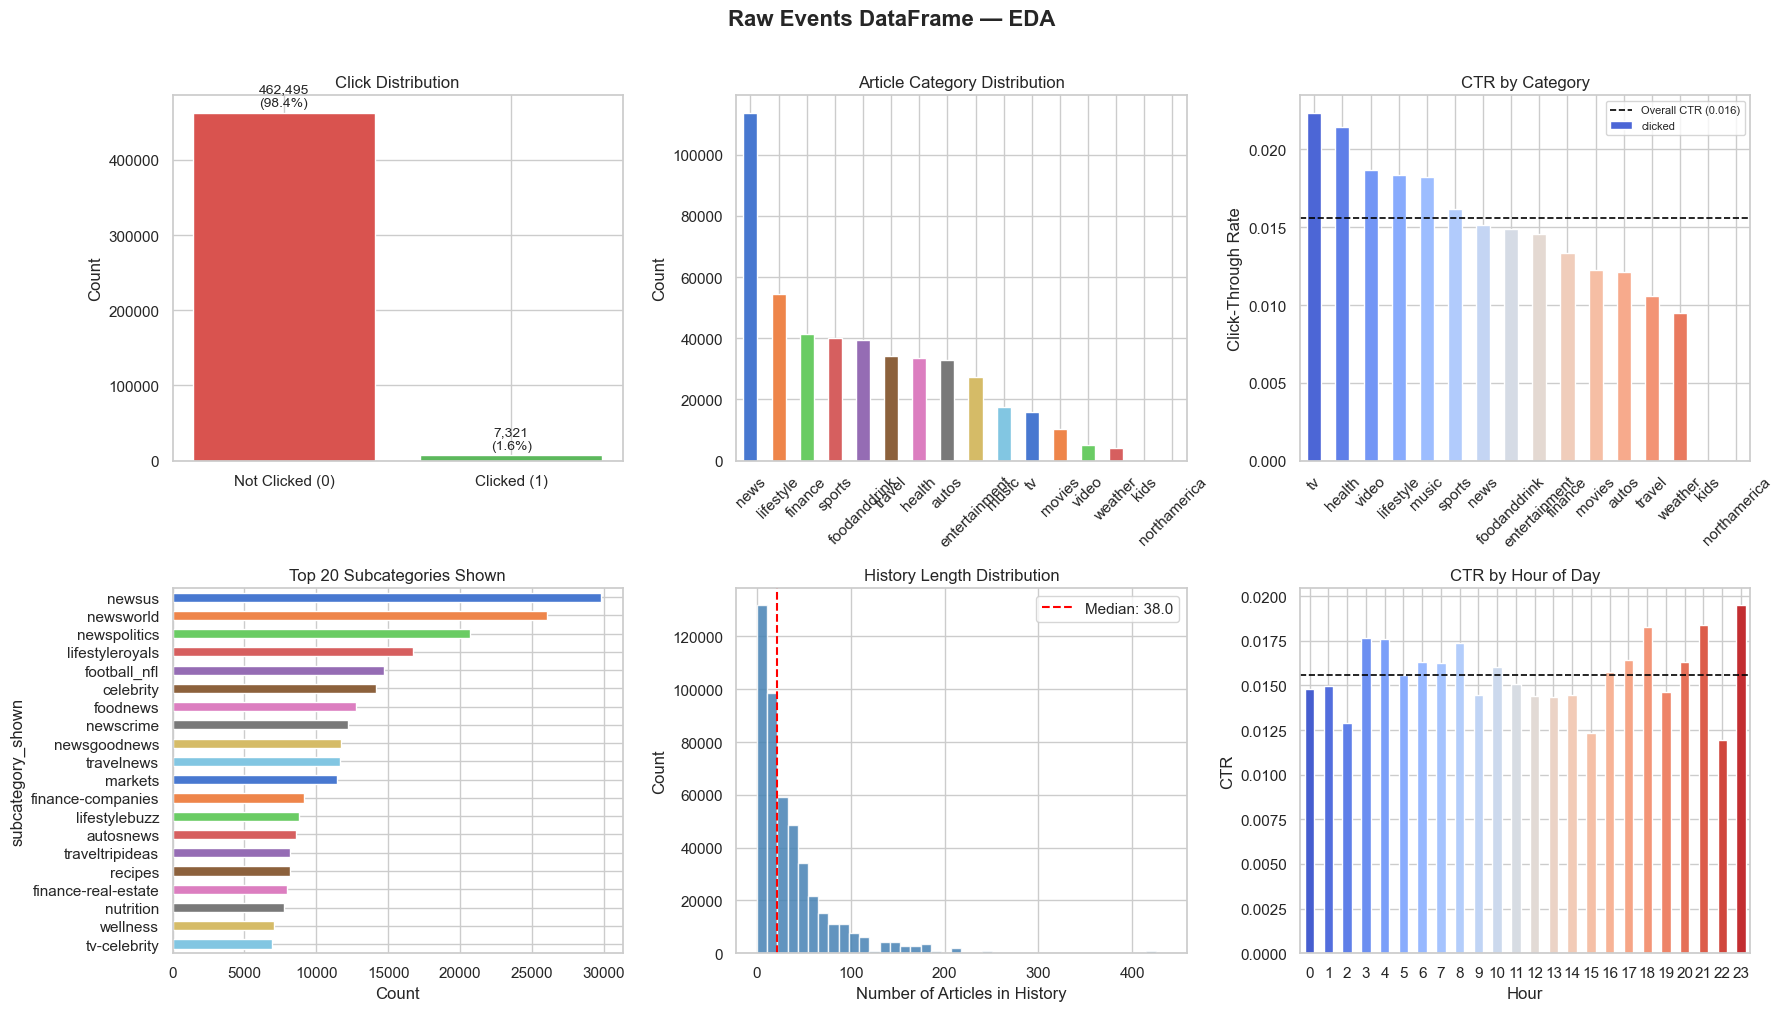

events_df shape: (469816, 9)
Overall CTR: 0.0156


In [170]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Raw Events DataFrame — EDA', fontsize=16, fontweight='bold', y=1.01)

# ── 1. Overall Click Rate ────────────────────────────────────────────────────
ax = axes[0, 0]
click_counts = events_df['clicked'].value_counts()
ax.bar(['Not Clicked (0)', 'Clicked (1)'], click_counts.values,
       color=['#d9534f', '#5cb85c'], edgecolor='white')
for i, v in enumerate(click_counts.values):
    ax.text(i, v + max(click_counts.values) * 0.01, f'{v:,}\n({v/len(events_df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10)
ax.set_title('Click Distribution')
ax.set_ylabel('Count')

# ── 2. Category Distribution of Shown Articles ───────────────────────────────
ax = axes[0, 1]
cat_counts = events_df['category_shown'].value_counts()
cat_counts.plot(kind='bar', ax=ax, color=sns.color_palette('muted', len(cat_counts)), edgecolor='white')
ax.set_title('Article Category Distribution')
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)

# ── 3. CTR by Category ───────────────────────────────────────────────────────
ax = axes[0, 2]
ctr_by_cat = events_df.groupby('category_shown')['clicked'].mean().sort_values(ascending=False)
ctr_by_cat.plot(kind='bar', ax=ax, color=sns.color_palette('coolwarm', len(ctr_by_cat)), edgecolor='white')
ax.axhline(events_df['clicked'].mean(), color='black', linestyle='--', linewidth=1.2, label=f'Overall CTR ({events_df["clicked"].mean():.3f})')
ax.set_title('CTR by Category')
ax.set_xlabel('')
ax.set_ylabel('Click-Through Rate')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=8)

# ── 4. Top 20 Subcategories ──────────────────────────────────────────────────
ax = axes[1, 0]
top_subcats = events_df['subcategory_shown'].value_counts().head(20)
top_subcats.plot(kind='barh', ax=ax, color=sns.color_palette('muted', 20), edgecolor='white')
ax.set_title('Top 20 Subcategories Shown')
ax.set_xlabel('Count')
ax.invert_yaxis()

# ── 5. History Length Distribution ───────────────────────────────────────────
ax = axes[1, 1]
hist_lengths = events_df['history'].apply(len)
ax.hist(hist_lengths, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(hist_lengths.median(), color='red', linestyle='--', linewidth=1.5, label=f'Median: {hist_lengths.mean():.1f}')
ax.set_title('History Length Distribution')
ax.set_xlabel('Number of Articles in History')
ax.set_ylabel('Count')
ax.legend()

"""
# ── 6. Impressions Over Time ─────────────────────────────────────────────────
ax = axes[1, 2]
events_df['time'].dt.date.value_counts().sort_index().plot(ax=ax, color='steelblue', linewidth=2)
ax.set_title('Impressions Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Impressions')
ax.tick_params(axis='x', rotation=30)
"""

"""
# ── 7. Semantic Similarity (Title Entities) — Clicked vs Not ─────────────────
ax = axes[2, 0]
for label, grp in events_df.groupby('clicked'):
    ax.hist(grp['semantic_similarity_title_entities'], bins=40, alpha=0.6,
            label='Clicked' if label == 1 else 'Not Clicked', edgecolor='white')
ax.set_title('Semantic Similarity — Title Entities')
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Count')
ax.legend()
"""

"""
# ── 8. Semantic Similarity (Abstract Entities) — Clicked vs Not ──────────────
ax = axes[2, 1]
for label, grp in events_df.groupby('clicked'):
    ax.hist(grp['semantic_similarity_abstract_entities'], bins=40, alpha=0.6,
            label='Clicked' if label == 1 else 'Not Clicked', edgecolor='white')
ax.set_title('Semantic Similarity — Abstract Entities')
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Count')
ax.legend()
"""
# ── 9. CTR by Hour of Day ────────────────────────────────────────────────────
ax = axes[1, 2]
ctr_by_hour = events_df.groupby(events_df['time'].dt.hour)['clicked'].mean()
ctr_by_hour.plot(kind='bar', ax=ax, color=sns.color_palette('coolwarm', len(ctr_by_hour)), edgecolor='white')
ax.axhline(events_df['clicked'].mean(), color='black', linestyle='--', linewidth=1.2)
ax.set_title('CTR by Hour of Day')
ax.set_xlabel('Hour')
ax.set_ylabel('CTR')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()
print(f'events_df shape: {events_df.shape}')
print(f'Overall CTR: {events_df["clicked"].mean():.4f}')


## **Post-Feature-Engineering EDA (`featured_df`)**
Visualising engineered features and their relationship with the click label.

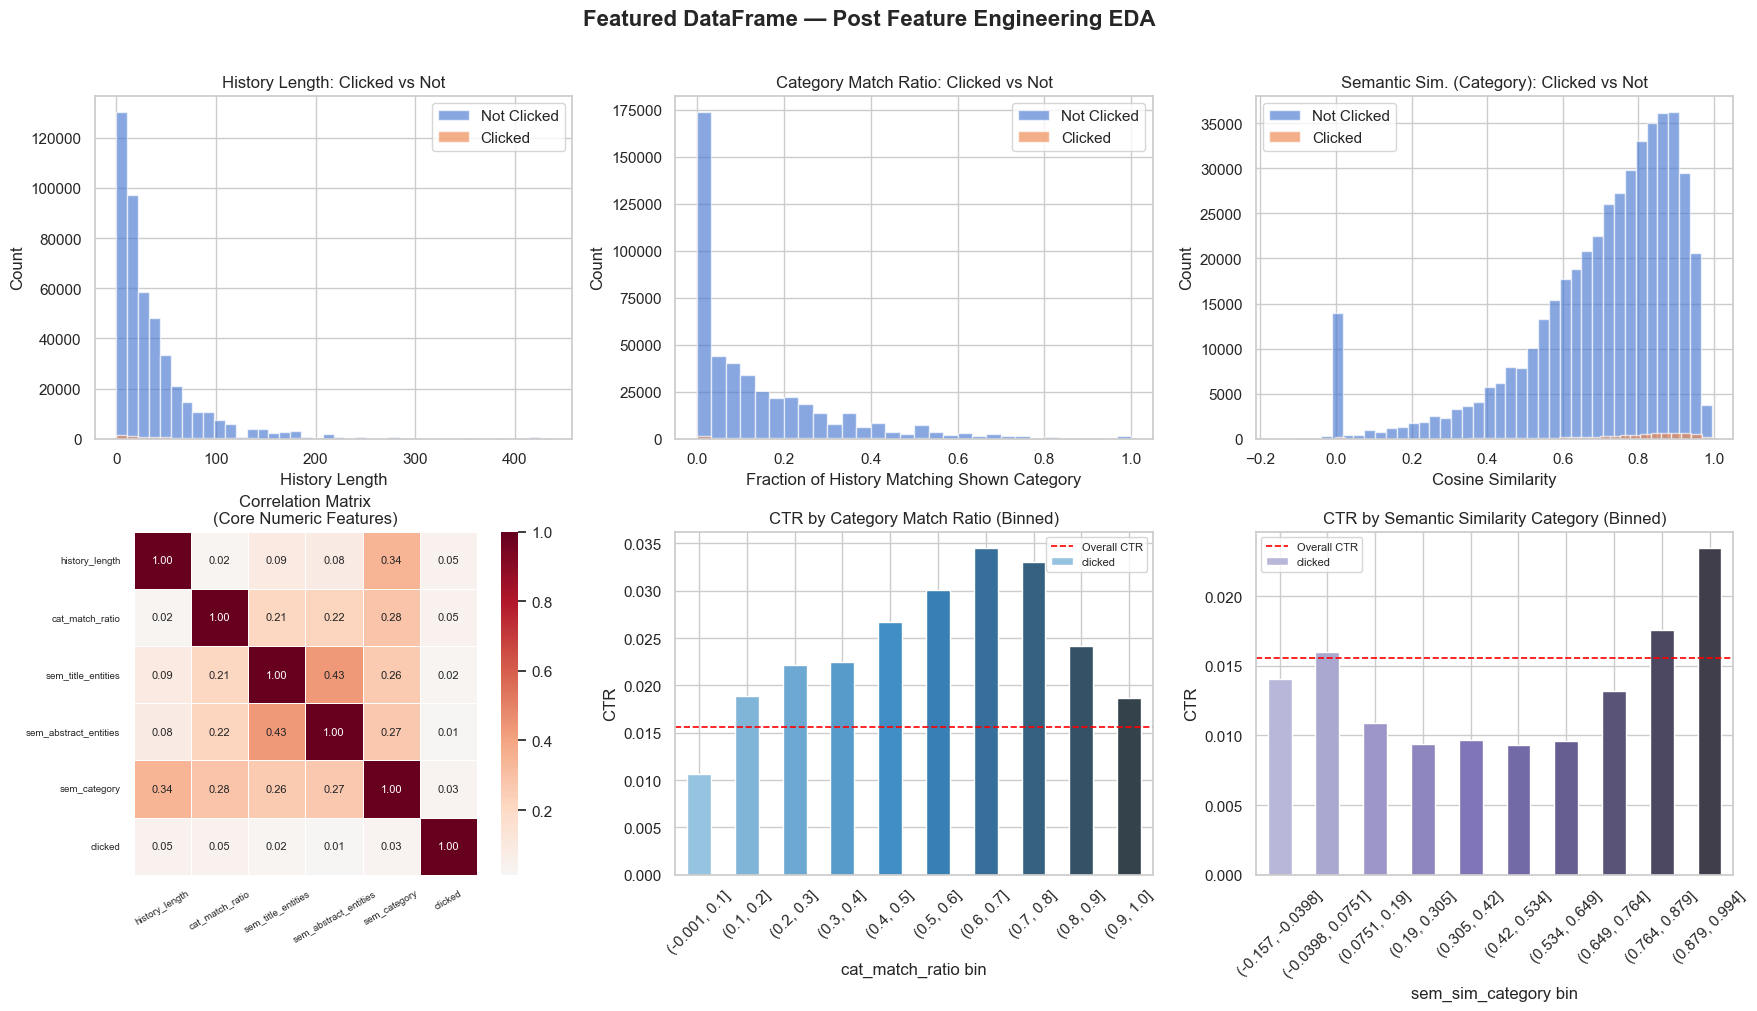

featured_df shape: (469816, 29)
Columns added vs events_df: ['history_length', 'cat_match_ratio', 'hist_pct_autos', 'hist_pct_entertainment', 'hist_pct_finance', 'hist_pct_foodanddrink', 'hist_pct_health', 'hist_pct_kids', 'hist_pct_lifestyle', 'hist_pct_middleeast', 'hist_pct_movies', 'hist_pct_music', 'hist_pct_news', 'hist_pct_northamerica', 'hist_pct_sports', 'hist_pct_travel', 'hist_pct_tv', 'hist_pct_video', 'hist_pct_weather', 'semantic_similarity_category']


In [171]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
all_categories_sorted = sorted(featured_df['category_shown'].unique().tolist())
hist_pct_cols = [f'hist_pct_{c}' for c in all_categories_sorted]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Featured DataFrame — Post Feature Engineering EDA', fontsize=16, fontweight='bold', y=1.01)

# ── 1. History Length: Clicked vs Not ───────────────────────────────────────
ax = axes[0, 0]
for label, grp in featured_df.groupby('clicked'):
    ax.hist(grp['history_length'], bins=40, alpha=0.65,
            label='Clicked' if label == 1 else 'Not Clicked', edgecolor='white')
ax.set_title('History Length: Clicked vs Not')
ax.set_xlabel('History Length')
ax.set_ylabel('Count')
ax.legend()

# ── 2. Category Match Ratio Distribution ────────────────────────────────────
ax = axes[0, 1]
for label, grp in featured_df.groupby('clicked'):
    ax.hist(grp['cat_match_ratio'], bins=30, alpha=0.65,
            label='Clicked' if label == 1 else 'Not Clicked', edgecolor='white')
ax.set_title('Category Match Ratio: Clicked vs Not')
ax.set_xlabel('Fraction of History Matching Shown Category')
ax.set_ylabel('Count')
ax.legend()

# ── 3. Semantic Similarity (Category) — Clicked vs Not ──────────────────────
ax = axes[0, 2]
for label, grp in featured_df.groupby('clicked'):
    ax.hist(grp['semantic_similarity_category'], bins=40, alpha=0.65,
            label='Clicked' if label == 1 else 'Not Clicked', edgecolor='white')
ax.set_title('Semantic Sim. (Category): Clicked vs Not')
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Count')
ax.legend()

"""
# ── 4. Mean hist_pct per Category — Clicked vs Not (grouped bar) ────────────
ax = axes[1, 0]
mean_pct_clicked = featured_df[featured_df['clicked'] == 1][hist_pct_cols].mean()
mean_pct_notclicked = featured_df[featured_df['clicked'] == 0][hist_pct_cols].mean()
x = np.arange(len(all_categories_sorted))
width = 0.4
ax.bar(x - width/2, mean_pct_clicked.values, width, label='Clicked', color='#5cb85c', alpha=0.8)
ax.bar(x + width/2, mean_pct_notclicked.values, width, label='Not Clicked', color='#d9534f', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(all_categories_sorted, rotation=45, ha='right', fontsize=8)
ax.set_title('Mean hist_pct per Category\n(Clicked vs Not)')
ax.set_ylabel('Mean Fraction in History')
ax.legend(fontsize=8)

# ── 5. Feature Distributions: Box Plot for numeric features ─────────────────
ax = axes[1, 1]

plot_data = [
    featured_df[featured_df['clicked'] == 1][col].dropna().values
    for col in core_numeric
]
bp = ax.boxplot(plot_data, patch_artist=True, labels=[c.replace('semantic_similarity_', 'sem_sim_') for c in core_numeric])
for patch, color in zip(bp['boxes'], sns.color_palette('muted', len(core_numeric))):
    patch.set_facecolor(color)
ax.set_title('Numeric Feature Distributions (Clicked=1)')
ax.tick_params(axis='x', rotation=30)
ax.set_ylabel('Value')
"""
core_numeric = ['history_length', 'cat_match_ratio',
                'semantic_similarity_title_entities',
                'semantic_similarity_abstract_entities',
                'semantic_similarity_category']
# ── 6. Correlation: Core Numeric Features with Click ────────────────────────
ax = axes[1, 0]
corr_features = core_numeric + ['clicked']
corr_matrix = featured_df[corr_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, square=True, linewidths=0.5, annot_kws={'size': 8},
            xticklabels=[c.replace('semantic_similarity_', 'sem_') for c in corr_features],
            yticklabels=[c.replace('semantic_similarity_', 'sem_') for c in corr_features])
ax.set_title('Correlation Matrix\n(Core Numeric Features)')
ax.tick_params(axis='x', rotation=30, labelsize=7)
ax.tick_params(axis='y', rotation=0, labelsize=7)

"""
# ── 7. hist_pct Heatmap across all categories ────────────────────────────────
ax = axes[2, 0]
heatmap_data = featured_df.groupby('category_shown')[hist_pct_cols].mean()
heatmap_data.columns = [c.replace('hist_pct_', '') for c in heatmap_data.columns]
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, annot=False, linewidths=0.3)
ax.set_title('Avg hist_pct per Shown Category\n(User History Profile)')
ax.set_xlabel('History Category')
ax.set_ylabel('Shown Category')
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', rotation=0, labelsize=7)
"""

# ── 8. CTR vs cat_match_ratio (binned) ───────────────────────────────────────
ax = axes[1, 1]
featured_df['cat_match_bin'] = pd.cut(featured_df['cat_match_ratio'],
                                       bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
                                       include_lowest=True)
ctr_vs_match = featured_df.groupby('cat_match_bin', observed=True)['clicked'].mean()
ctr_vs_match.plot(kind='bar', ax=ax, color=sns.color_palette('Blues_d', len(ctr_vs_match)), edgecolor='white')
ax.axhline(featured_df['clicked'].mean(), color='red', linestyle='--', linewidth=1.2, label='Overall CTR')
ax.set_title('CTR by Category Match Ratio (Binned)')
ax.set_xlabel('cat_match_ratio bin')
ax.set_ylabel('CTR')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=8)
featured_df.drop(columns=['cat_match_bin'], inplace=True)

# ── 9. CTR vs Semantic Similarity Category (binned) ──────────────────────────
ax = axes[1, 2]
featured_df['sem_sim_bin'] = pd.cut(featured_df['semantic_similarity_category'],
                                     bins=10, include_lowest=True)
ctr_vs_sem = featured_df.groupby('sem_sim_bin', observed=True)['clicked'].mean()
ctr_vs_sem.plot(kind='bar', ax=ax, color=sns.color_palette('Purples_d', len(ctr_vs_sem)), edgecolor='white')
ax.axhline(featured_df['clicked'].mean(), color='red', linestyle='--', linewidth=1.2, label='Overall CTR')
ax.set_title('CTR by Semantic Similarity Category (Binned)')
ax.set_xlabel('sem_sim_category bin')
ax.set_ylabel('CTR')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=8)
featured_df.drop(columns=['sem_sim_bin'], inplace=True)

plt.tight_layout()
plt.show()
print(f'featured_df shape: {featured_df.shape}')
print(f'Columns added vs events_df: {[c for c in featured_df.columns if c not in events_df.columns]}')


In [172]:
print(featured_df.shape)
display(featured_df.head(3))

(469816, 29)


,impression_id,time,history,article_shown,clicked,category_shown,subcategory_shown,semantic_similarity_title_entities,semantic_similarity_abstract_entities,history_length,...,hist_pct_movies,hist_pct_music,hist_pct_news,hist_pct_northamerica,hist_pct_sports,hist_pct_travel,hist_pct_tv,hist_pct_video,hist_pct_weather,semantic_similarity_category
0,7,2019-11-11 12:22:09,"[N8419, N15771, N1431, N5888, N18663, N24123, ...",N51346,0,sports,football_nfl,0.484891,0.569189,35,...,0.057143,0.028571,0.371429,0.0,0.171429,0.028571,0.057143,0.0,0.0,0.800008
1,7,2019-11-11 12:22:09,"[N8419, N15771, N1431, N5888, N18663, N24123, ...",N33848,0,sports,football_nfl_videos,0.000000,0.258095,35,...,0.057143,0.028571,0.371429,0.0,0.171429,0.028571,0.057143,0.0,0.0,0.800008
2,7,2019-11-11 12:22:09,"[N8419, N15771, N1431, N5888, N18663, N24123, ...",N15132,0,news,newsworld,0.641133,0.754591,35,...,0.057143,0.028571,0.371429,0.0,0.171429,0.028571,0.057143,0.0,0.0,0.860789


In [173]:
# featured_df.to_csv("featured_df.csv", index=False)
# load featured_df
# featured_df = pd.read_csv("featured_df.csv")

Number of arms:

In [ ]:
#Sort chronologically once, then use this ordering consistently throughout.
#MIND timestamps are strings, so parse them before sorting to avoid
# lexicographic ordering errors.

short_df = featured_df.copy()
short_df['_time_parsed'] = pd.to_datetime(short_df['time'], errors='coerce')

missing_time = short_df['_time_parsed'].isna().sum()
if missing_time > 0:
    print(f"Warning: {missing_time:,} rows have unparseable timestamps.")

short_df = short_df.sort_values(['_time_parsed', 'impression_id']).reset_index(drop=True)

print(f"short_df shape: {short_df.shape}")
print(f"Columns: {list(short_df.columns)}")
print(f"Time range: {short_df['_time_parsed'].min()} → {short_df['_time_parsed'].max()}")
print(f"Click rate: {short_df['clicked'].mean():.4f}")


short_df shape: (469816, 30)
Columns: ['impression_id', 'time', 'history', 'article_shown', 'clicked', 'category_shown', 'subcategory_shown', 'semantic_similarity_title_entities', 'semantic_similarity_abstract_entities', 'history_length', 'cat_match_ratio', 'hist_pct_autos', 'hist_pct_entertainment', 'hist_pct_finance', 'hist_pct_foodanddrink', 'hist_pct_health', 'hist_pct_kids', 'hist_pct_lifestyle', 'hist_pct_middleeast', 'hist_pct_movies', 'hist_pct_music', 'hist_pct_news', 'hist_pct_northamerica', 'hist_pct_sports', 'hist_pct_travel', 'hist_pct_tv', 'hist_pct_video', 'hist_pct_weather', 'semantic_similarity_category', '_time_parsed']
Time range: 2019-11-09 00:36:31 → 2019-11-14 23:46:16
Click rate: 0.0156


In [ ]:
arms = sorted(short_df['category_shown'].unique().tolist())
n_arms = len(arms)
arm_to_idx = {a: i for i, a in enumerate(arms)}

print(f"Number of arms (categories): {n_arms}")
print(f"Arms: {arms}")

Number of arms (categories): 16
Arms: ['autos', 'entertainment', 'finance', 'foodanddrink', 'health', 'kids', 'lifestyle', 'movies', 'music', 'news', 'northamerica', 'sports', 'travel', 'tv', 'video', 'weather']


---

# **Checkpoint 2**

`featured_df` has now been built. Now, lets use these features to create a logistic regression model, and create the *true estimated reward* for each user.

In the previous code what we did was just directly throw `cat_match` into the model and train. However, you cannot do that because that is the category match of the HISTORICALLY shown category, and it created a situation where it gave the same true estimated value for every arm.

One solution will be to split our dataset into the 16 different categories shown, create 16 different logreg models based on each arm, and use each one individually to predict the probability of each arm for every user.

The other solution (which we used below) involves the use of interaction terms in the logreg model. For example:
$$Z = \dots + \theta_1 (\text{hist\_pct\_sports}) + \theta_2 (\text{is\_sports}) + \theta_3 (\text{hist\_pct\_sports} \times \text{is\_sports})$$

1. The Standalone $\theta_1$ becomes the "Baseline Clickiness"The model uses $\theta_1$ to answer: "Regardless of what article I show them, are people who read a lot of sports just generally click-happy?"If sports fans are normal people, the model will just learn a $\theta_1$ very close to 0. It realizes, "I don't need to boost this person's score globally just because they like sports." It leaves the standalone term alone.

2. The Standalone $\theta_2$ becomes the "Global Popularity"The model uses $\theta_2$ to answer: "Regardless of who the user is, is this sports article just a really good, click-bait article?"

3. The Interaction $\theta_3$ becomes the "Personalized Match"This is where the magic happens. The model uses $\theta_3$ to answer: "When a sports fan is specifically shown a sports article, how much EXTRA do they click?"Because the model can now isolate this specific scenario, $\theta_3$ will become a massive positive number.

---

# **Create Log Reg Model**

(Just take note we save the logreg to a variable called `reward_model`. This is legacy code and we dont change the name here to avoid the code breaking downstream. Strictly speaking according to the definition i set, this is the true reward estimate model.)

In [176]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)


In [177]:
hist_pct_features = [f'hist_pct_{c}' for c in all_categories]

numeric_features     = ['history_length', 'semantic_similarity_category'] + hist_pct_features

# use category_shown
# This allows the model to know which article is actually being evaluated
categorical_features = ['category_shown']
feature_columns      = numeric_features + categorical_features
target = 'clicked'

print(f"Numeric features:     {numeric_features}")
print(f"Categorical features: {categorical_features}")
print(f"Target:               {target}")

Numeric features:     ['history_length', 'semantic_similarity_category', 'hist_pct_autos', 'hist_pct_entertainment', 'hist_pct_finance', 'hist_pct_foodanddrink', 'hist_pct_health', 'hist_pct_kids', 'hist_pct_lifestyle', 'hist_pct_middleeast', 'hist_pct_movies', 'hist_pct_music', 'hist_pct_news', 'hist_pct_northamerica', 'hist_pct_sports', 'hist_pct_travel', 'hist_pct_tv', 'hist_pct_video', 'hist_pct_weather']
Categorical features: ['category_shown']
Target:               clicked


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

reward_model = Pipeline([
    ('preprocessor', preprocessor),

    # 2. ADD THE INTERACTION GENERATOR
    # interaction_only=True ensures we get (A * B) but avoids squaring features (no A^2)
    # include_bias=False prevents adding a redundant intercept column
    ('interactions', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),

    ('classifier', LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42, class_weight='balanced'))
])

## The reward model is trained on earlier logged impressions and evaluated on
## later held-out impressions. We split by impression_id, not raw rows, to avoid
## putting different candidate articles from the same impression in both sets.

impression_order = (
    short_df[['impression_id', '_time_parsed']]
    .drop_duplicates(subset=['impression_id'])
    .sort_values(['_time_parsed', 'impression_id'])
    .reset_index(drop=True)
)

split_idx = int(0.8 * len(impression_order))

train_impression_ids = set(impression_order.iloc[:split_idx]['impression_id'])
test_impression_ids  = set(impression_order.iloc[split_idx:]['impression_id'])

reward_train_df = short_df[short_df['impression_id'].isin(train_impression_ids)].copy()
reward_test_df  = short_df[short_df['impression_id'].isin(test_impression_ids)].copy()

#keep each split chronologically ordered for downstream offline simulation.
reward_train_df = reward_train_df.sort_values(['_time_parsed', 'impression_id']).reset_index(drop=True)
reward_test_df  = reward_test_df.sort_values(['_time_parsed', 'impression_id']).reset_index(drop=True)

X_train = reward_train_df[feature_columns]
y_train = reward_train_df[target]

X_test = reward_test_df[feature_columns]
y_test = reward_test_df[target]

print(f"Train period: {reward_train_df['_time_parsed'].min()} → {reward_train_df['_time_parsed'].max()}")
print(f"Test period:  {reward_test_df['_time_parsed'].min()} → {reward_test_df['_time_parsed'].max()}")
print(f"Train impressions: {len(train_impression_ids):,} | Test impressions: {len(test_impression_ids):,}")
print(f"Train rows: {X_train.shape[0]:,} | Test rows: {X_test.shape[0]:,}")
print(f"Train click rate: {y_train.mean():.4f} | Test click rate: {y_test.mean():.4f}")


Train period: 2019-11-09 00:36:31 → 2019-11-14 06:11:45
Test period:  2019-11-14 06:12:15 → 2019-11-14 23:46:16
Train impressions: 1,959 | Test impressions: 490
Train rows: 374,874 | Test rows: 94,942
Train click rate: 0.0156 | Test click rate: 0.0154


In [ ]:
reward_model.fit(X_train, y_train)

y_pred_proba = reward_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)

y_pred = reward_model.predict(X_test)

print(f"\nReward Model AUC: {auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Clicked', 'Clicked']))


Reward Model AUC: 0.6598

Classification Report:
              precision    recall  f1-score   support

 Not Clicked       0.99      0.62      0.77     93481
     Clicked       0.02      0.61      0.05      1461

    accuracy                           0.62     94942
   macro avg       0.51      0.62      0.41     94942
weighted avg       0.98      0.62      0.75     94942



The AUC of our logreg model is 0.6598. Mathematically, an AUC of 0.6598 means this: If you take one random article that a user actually clicked, and one random article they didn't click, your Oracle model has a 65.98% chance of correctly scoring the clicked article higher than the ignored one.

It is noticeably better than a coin flip (50%), meaning your model has definitely learned real signals (like the interaction terms and semantic similarity!). However, it is far from a perfect crystal ball (100%).

---
## **Sanity check: Print the coefficients of the logreg model**
When this prints out, you will likely see your interaction terms dominating the top of the list!Look specifically for combinations like hist_pct_sports category_shown_sports or semantic_similarity_category category_shown_finance. If those coefficients are massive positive numbers, it proves your model successfully learned the exact "Personalized Match" ($\theta_3$) logic we just talked about!

In [ ]:
preprocessor = reward_model.named_steps['preprocessor']
cat_encoder = preprocessor.named_transformers_['cat']
cat_features_out = cat_encoder.get_feature_names_out(categorical_features)

base_features = numeric_features + list(cat_features_out)

poly = reward_model.named_steps['interactions']
poly_features = poly.get_feature_names_out(base_features)

classifier = reward_model.named_steps['classifier']
coefficients = classifier.coef_[0]

coef_df = pd.DataFrame({
    'Feature': poly_features,
    'Coefficient': coefficients
})

coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).drop(columns=['Abs_Coefficient'])

print("--- Top 20 Most Impactful Features & Interactions ---")
print(coef_df.head(20).to_string(index=False))

print(f"\nModel Intercept (Baseline Bias): {classifier.intercept_[0]:.4f}")

--- Top 20 Most Impactful Features & Interactions ---
                                            Feature  Coefficient
               hist_pct_health category_shown_video    -0.810331
                   hist_pct_tv category_shown_video    -0.674643
  semantic_similarity_category category_shown_video     0.604212
               hist_pct_sports category_shown_video    -0.548368
          hist_pct_lifestyle category_shown_weather    -0.536182
                 hist_pct_news category_shown_video    -0.532334
                                  category_shown_tv     0.513025
                             category_shown_weather    -0.506247
                              category_shown_health     0.498799
              hist_pct_finance category_shown_video    -0.485831
            hist_pct_lifestyle category_shown_video    -0.463179
                               category_shown_video    -0.414067
                history_length category_shown_video    -0.413033
       hist_pct_foodanddrink categor

---
# **Precompute steps**

## **Creating counterfactual**
Basically when our MAB pulls a category we havent seen before, it needs to calculate the `semantic_similarity_category` of this new category. Instead of doing it during the simulate loop, we create a dictionary and calculate it beforehand, so the MAB can just access the dictionary and pull these values.

(What it does:)
It iterates through every unique user impression. For each user, it looks at their historical Knowledge Graph (KG) vectors, and calculates the mathematical Cosine Similarity against all 16 category KG vectors. It saves these floats in a dictionary where the key is (User ID, Category).

Why it is necessary: During the live simulation, your bandit is going to evaluate thousands of arms per second. If Python had to run heavy matrix math (vector norms and dot products) every single time an agent considered pulling an arm, your simulation would take hours. By precomputing the distances and storing them in a fast dictionary, the bandit can just do a lightning-fast O(1) lookup.

In [ ]:
print("Precomputing semantic similarity for all impression × arm combinations...")
start_time = time.time()

def cosine(a, b):
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / denom) if denom > 1e-9 else 0.0

unique_impression_ids = events_df['impression_id'].unique()

sem_sim_lookup = {}

for imp_id in unique_impression_ids:
    h_title    = history_title_kg_vec.get(imp_id, np.zeros(KG_DIM, dtype=np.float32))
    h_abstract = history_abstract_kg_vec.get(imp_id, np.zeros(KG_DIM, dtype=np.float32))
    for arm in all_categories:
        c_title    = category_title_kg_vec[arm]
        c_abstract = category_abstract_kg_vec[arm]
        sem_sim_lookup[(imp_id, arm)] = (cosine(h_title, c_title) + cosine(h_abstract, c_abstract)) / 2.0

minutes = (time.time() - start_time) / 60
print(f"Finished in {minutes:.2f} minutes.")
print(f"Lookup table size: {len(sem_sim_lookup):,} entries ({len(unique_impression_ids):,} impressions × {len(all_categories)} arms)")



Precomputing semantic similarity for all impression × arm combinations...
Finished in 0.00 minutes.
Lookup table size: 41,633 entries (2,449 impressions × 17 arms)


## **Reward Model**

This is the reward model, converting the probability to the Reward (1 or 0). Take note of the `np.random.binomial` which is basically our binomial distribution reward model!

Try it out: there is a print statement at the bottom, testing on a random user 100 with probability of about 0.2. If you keep running the code, you will notice that about 20% of the time the click will be 1, while the rest of the time it will be 0. This is a demonstration of the binomial distribution reward.

In [ ]:
# NOTE:
# This is a model-based offline evaluation.
# The reward model is trained only on earlier logged data.
# During bandit evaluation, it acts as a fixed environment simulator for later
# held-out impressions. The bandit algorithms do not directly access
# reward_model during arm selection.

def simulate_reward(context_row, arm_category, reward_model,
                    all_categories, sem_sim_lookup):
    """
    Simulate a binary click reward using the trained reward model.

    Parameters
    ----------
    context_row : dict or pd.Series
        Must contain the numeric feature values for this user-impression.
    arm_category : str
        The category (arm) being recommended.
    reward_model : fitted sklearn Pipeline
        The logistic regression reward model.
    all_categories : list
        Full list of category arm names.
    sem_sim_lookup : dict
        Precomputed (impression_id, arm) → semantic similarity float.

    Returns
    -------
    reward : int (0 or 1)
    prob   : float  (predicted click probability)
    """

    imp_id  = context_row['impression_id']
    sem_sim = sem_sim_lookup.get((imp_id, arm_category), 0.0)

    row = {
        'history_length':               context_row['history_length'],
        'semantic_similarity_category': sem_sim,
        'category_shown':               arm_category,
        **{f'hist_pct_{c}': context_row[f'hist_pct_{c}'] for c in all_categories}
    }

    df_input = pd.DataFrame([row])
    prob     = reward_model.predict_proba(df_input)[:, 1][0]
    reward   = np.random.binomial(1, prob)
    return reward, prob

sample = reward_test_df.iloc[min(100, len(reward_test_df) - 1)]
r, p = simulate_reward(
    sample, sample['category_shown'], reward_model,
    all_categories, sem_sim_lookup
)
print(f"Sample reward: {r}, predicted prob: {p:.4f}")


Sample reward: 0, predicted prob: 0.4291


## **Extract context vector**
This code extracts the context vector from each user.

Contains `history_length`, `semantic_similarity_category`, and `hist_pct_*` (one for each arm).

In [ ]:
## The simulation itself is prepared below using reward_test_df only. For each
## held-out impression, the MAB picks an arm and the reward model simulates
## whether the user would have clicked.

hist_pct_features = [f'hist_pct_{c}' for c in all_categories]

def get_context_vector(context_row, arm_category, sem_sim_lookup):
    """
    Extract the context features as a numpy vector for a specific arm.
    Since semantic_similarity_category varies per arm, arm_category is required.

    Parameters
    ----------
    context_row : pd.Series
        A row from sim_df containing user/impression features.
    arm_category : str
        The arm being evaluated — needed to fetch the correct sem_sim.
    sem_sim_lookup : dict
        Precomputed (impression_id, arm) → semantic similarity float.
    """
    imp_id  = context_row['impression_id']
    sem_sim = sem_sim_lookup.get((imp_id, arm_category), 0.0)

    return np.array([
        context_row['history_length'],
        sem_sim,
        *[context_row[f'hist_pct_{c}'] for c in all_categories]
    ], dtype=np.float64)

# Context dimension: history_length + semantic_sim + one hist_pct per category
d = 1 + 1 + len(all_categories)
print(f"Context dimension d = {d}")
print(f"  history_length:               1")
print(f"  semantic_similarity_category: 1")
print(f"  hist_pct_* columns:           {len(all_categories)}")


Context dimension d = 19
  history_length:               1
  semantic_similarity_category: 1
  hist_pct_* columns:           17


---
## **Sanity check: Print the True Estimated Reward**
Print for the first 10 users:

In [184]:
# ── Oracle Probabilities for Held-out Impressions ────────────────────────────
# Display the first 10 unique impressions from the future evaluation stream.
unique_sim_df = reward_test_df.drop_duplicates(subset=['impression_id']).head(10)

print(f"{'Impression':<10} | {'Best Arm':<22} | {'All Estimated Rewards'}")
print("-" * 110)

for i in range(len(unique_sim_df)):
    context_row = unique_sim_df.iloc[i]
    imp_id      = context_row['impression_id']

    # Create candidate rows for all arms for this single held-out impression.
    user_scenarios = []
    for arm in arms:
        sem_sim = sem_sim_lookup.get((imp_id, arm), 0.0)
        user_scenarios.append({
            'history_length':               context_row['history_length'],
            'semantic_similarity_category': sem_sim,
            'category_shown':               arm,
            **{f'hist_pct_{c}': context_row[f'hist_pct_{c}'] for c in all_categories}
        })

    user_df   = pd.DataFrame(user_scenarios)
    all_probs = reward_model.predict_proba(user_df)[:, 1]

    best_arm        = np.argmax(all_probs)
    formatted_probs = ", ".join([f"{p:.4f}" for p in all_probs])

    print(f"Imp {imp_id:<6} | Arm {best_arm:<2} ({arms[best_arm]:<15}) | [{formatted_probs}]")


Impression | Best Arm               | All Estimated Rewards
--------------------------------------------------------------------------------------------------------------
Imp 2561   | Arm 13 (tv             ) | [0.2388, 0.4291, 0.3204, 0.3230, 0.5331, 0.3278, 0.4472, 0.3088, 0.5780, 0.3424, 0.3510, 0.4745, 0.2735, 0.6135, 0.1815, 0.2497]
Imp 63502  | Arm 3  (foodanddrink   ) | [0.0577, 0.1247, 0.1371, 0.7885, 0.3210, 0.2161, 0.2164, 0.0976, 0.2652, 0.0466, 0.1898, 0.0688, 0.3884, 0.1680, 0.1272, 0.6729]
Imp 26393  | Arm 11 (sports         ) | [0.2909, 0.2243, 0.3322, 0.1663, 0.4762, 0.3244, 0.1688, 0.2489, 0.2930, 0.2223, 0.3370, 0.7526, 0.2364, 0.3723, 0.0855, 0.4558]
Imp 62119  | Arm 4  (health         ) | [0.3451, 0.4430, 0.3872, 0.3740, 0.5607, 0.4165, 0.5172, 0.3826, 0.5092, 0.5233, 0.4323, 0.3536, 0.3848, 0.5578, 0.5249, 0.3544]
Imp 81109  | Arm 3  (foodanddrink   ) | [0.1557, 0.7291, 0.3881, 0.8882, 0.7968, 0.5531, 0.6981, 0.6778, 0.8054, 0.3030, 0.5552, 0.3452, 0.6910, 0.8231, 

---
# **Model OOPs**

In [ ]:
class NonDecayingEpsilonGreedy:
    """
    Contextual epsilon-greedy with a constant exploration rate.

    context_vectors : dict {arm_idx (int): np.array of shape (d,)}
    """

    def __init__(self, n_arms, d, epsilon=0.1, lambda_reg=1.0):
        self.n_arms = n_arms
        self.d = d
        self.epsilon = epsilon

        #per-arm ridge regression (identical structure to LinUCB)
        self.A = [lambda_reg * np.eye(d) for _ in range(n_arms)]
        self.b = [np.zeros(d) for _ in range(n_arms)]

        self.counts = np.zeros(n_arms)
        self.rewards = np.zeros(n_arms)
        self.epsilon_history = []

    def select_arm(self, context_vectors):
        """
        context_vectors : dict {arm_idx (int): np.array of shape (d,)}
            Each arm has its own context vector since
            semantic_similarity_category differs per arm.
        """
        self.epsilon_history.append(self.epsilon)

        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_arms)

        # exploit
        preds = np.zeros(self.n_arms)
        for a in range(self.n_arms):
            x = np.asarray(context_vectors[a], dtype=np.float64).ravel()
            A_inv = np.linalg.inv(self.A[a])
            theta_hat = A_inv @ self.b[a]
            preds[a] = theta_hat.dot(x)

        return int(np.argmax(preds))

    def update(self, arm_idx, context_vectors, reward):
        """
        arm_idx : int
            The arm that was chosen.
        context_vectors : dict {arm_idx: np.array}
            Same dict passed to select_arm.
        reward : int
            0 or 1.
        """
        x = np.asarray(context_vectors[arm_idx], dtype=np.float64).ravel()
        self.A[arm_idx] += np.outer(x, x)
        self.b[arm_idx] += reward * x
        self.counts[arm_idx] += 1
        self.rewards[arm_idx] += reward

    def get_avg_rewards(self):
        with np.errstate(divide='ignore', invalid='ignore'):
            avg = np.where(self.counts > 0, self.rewards / self.counts, 0.0)
        return avg

In [ ]:
class ContextualEpsilonGreedy:
    """
    Contextual Decaying Epsilon-Greedy

    Instead of querying the pre-trained reward model (which would give it
    an unfair oracle-like advantage), this class maintains per-arm ridge
    regression parameters — the same model family as LinUCB.

    Exploit  →  for each arm, predict  θ_a · x_a  and pick the argmax
    Explore  →  pick a uniform-random arm
    Update   →  standard ridge update  A_a += x xᵀ,  b_a += r · x

    The ONLY difference vs LinUCB is the exploration strategy:
      • Here: random ε-fraction (decaying)
      • LinUCB: confidence-bound bonus  α √(x A⁻¹ x)

    NOTE: select_arm now accepts a dict of {arm_idx: context_vector} because
    each arm has its own context vector (semantic_similarity_category differs
    per arm).
    """
    def __init__(self, n_arms, d, epsilon=0.3, decay_rate=0.99985,
                 epsilon_min=0.05, lambda_reg=1.0):
        self.n_arms      = n_arms
        self.d           = d
        self.epsilon     = epsilon
        self.decay_rate  = decay_rate
        self.epsilon_min = epsilon_min

        #per-arm ridge regression (identical structure to LinUCB)
        self.A = [lambda_reg * np.eye(d) for _ in range(n_arms)]
        self.b = [np.zeros(d)            for _ in range(n_arms)]

        self.counts  = np.zeros(n_arms)
        self.rewards = np.zeros(n_arms)
        self.epsilon_history = []

    def select_arm(self, context_vectors):
        """
        context_vectors : dict {arm_idx (int): np.array of shape (d,)}
            Each arm now has its OWN context vector since
            semantic_similarity_category differs per arm.
        """
        self.epsilon_history.append(self.epsilon)

        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_arms)

        # exploit
        preds = np.zeros(self.n_arms)
        for a in range(self.n_arms):
            x         = np.asarray(context_vectors[a], dtype=np.float64).ravel()
            A_inv     = np.linalg.inv(self.A[a])
            theta_hat = A_inv @ self.b[a]
            preds[a]  = theta_hat.dot(x)

        return int(np.argmax(preds))

    def update(self, arm_idx, context_vectors, reward):
        """
        arm_idx        : int — the arm that was chosen
        context_vectors: dict {arm_idx: np.array} — same dict passed to select_arm
        reward         : int (0 or 1)
        """
        x = np.asarray(context_vectors[arm_idx], dtype=np.float64).ravel()
        self.A[arm_idx] += np.outer(x, x)
        self.b[arm_idx] += reward * x
        self.counts[arm_idx]  += 1
        self.rewards[arm_idx] += reward
        self.epsilon = max(self.epsilon * self.decay_rate, self.epsilon_min)

    def get_avg_rewards(self):
        with np.errstate(divide='ignore', invalid='ignore'):
            avg = np.where(self.counts > 0, self.rewards / self.counts, 0.0)
        return avg

In [ ]:
class LinUCB:
    """
    LinUCB (Disjoint) contextual bandit.

    Maintains per-arm ridge regression parameters and selects
    the arm with the highest upper confidence bound.

    NOTE: select_arm now accepts a dict of {arm_idx: context_vector} because
    each arm has its own context vector (semantic_similarity_category differs
    per arm).
    """

    def __init__(self, n_arms, d, alpha=1.5):
        self.n_arms = n_arms
        self.d = d
        self.alpha = alpha

        #per-arm parameters
        self.A = [np.eye(d) for _ in range(n_arms)]
        self.b = [np.zeros(d) for _ in range(n_arms)]
        self.counts = np.zeros(n_arms)

        self.rewards = np.zeros(n_arms)

    def select_arm(self, context_vectors):
        """
        Select arm with highest UCB.
        Prediction = Contextual (Ridge Regression) using arm-specific x_a
        Bonus      = Non-Contextual (UCB1)

        context_vectors : dict {arm_idx (int): np.array of shape (d,)}
            Each arm has its OWN context vector since
            semantic_similarity_category differs per arm.
        """
        ucbs = np.zeros(self.n_arms)

        t = np.sum(self.counts) + 1

        for a in range(self.n_arms):
            x         = np.asarray(context_vectors[a], dtype=np.float64).ravel()
            A_inv     = np.linalg.inv(self.A[a])
            theta_hat = A_inv @ self.b[a]
            pred      = theta_hat @ x

            n = self.counts[a]
            if n == 0:
                bonus = float('inf')
            else:
                bonus = self.alpha * np.sqrt(x.T @ A_inv @ x)

            ucbs[a] = pred + bonus

        return int(np.argmax(ucbs))

    def update(self, arm_idx, context_vectors, reward):
        """
        arm_idx         : int — the arm that was chosen
        context_vectors : dict {arm_idx: np.array} — same dict passed to select_arm
        reward          : int (0 or 1)
        """
        x = np.asarray(context_vectors[arm_idx], dtype=np.float64).ravel()
        self.A[arm_idx] += np.outer(x, x)
        self.b[arm_idx] += reward * x
        self.counts[arm_idx] += 1

        self.rewards[arm_idx] += reward

In [ ]:
class ContextualThompsonSampling:
    """
    Linear Thompson Sampling (Disjoint) contextual bandit.

    Maintains per-arm Bayesian linear regression parameters and selects
    the arm by sampling θ_a ~ N(A_a⁻¹ b_a, v² A_a⁻¹) for each arm,
    then picking argmax_a (θ_a · x_a).

    NOTE: select_arm accepts a dict of {arm_idx: context_vector} because
    each arm has its own context vector (semantic_similarity_category differs
    per arm).
    """

    def __init__(self, n_arms, d, v=0.1, lambda_reg=1.0):
        self.n_arms = n_arms
        self.d = d
        self.v = v

        #per-arm ridge regression parameters (identical structure to LinUCB)
        self.A = [lambda_reg * np.eye(d) for _ in range(n_arms)]
        self.b = [np.zeros(d)            for _ in range(n_arms)]

        self.counts  = np.zeros(n_arms)
        self.rewards = np.zeros(n_arms)

    def select_arm(self, context_vectors):
        """
        context_vectors : dict {arm_idx (int): np.array of shape (d,)}
        """
        samples = np.zeros(self.n_arms)
        for a in range(self.n_arms):
            x       = np.asarray(context_vectors[a], dtype=np.float64).ravel()
            A_inv   = np.linalg.inv(self.A[a])
            mu      = A_inv @ self.b[a]
            theta_sample = np.random.multivariate_normal(mu, self.v ** 2 * A_inv)
            samples[a]   = theta_sample @ x
        return int(np.argmax(samples))

    def update(self, arm_idx, context_vectors, reward):
        """
        arm_idx         : int — the arm that was chosen
        context_vectors : dict {arm_idx: np.array} — same dict passed to select_arm
        reward          : int (0 or 1)
        """
        x = np.asarray(context_vectors[arm_idx], dtype=np.float64).ravel()
        self.A[arm_idx] += np.outer(x, x)
        self.b[arm_idx] += reward * x
        self.counts[arm_idx]  += 1
        self.rewards[arm_idx] += reward

    def get_avg_rewards(self):
        with np.errstate(divide='ignore', invalid='ignore'):
            avg = np.where(self.counts > 0, self.rewards / self.counts, 0.0)
        return avg


---
# **Initiate**

In [ ]:
## The bandit is evaluated only on later impressions that were NOT used to train
## the reward model.

sim_df = reward_test_df.sort_values(['_time_parsed', 'impression_id']).reset_index(drop=True)

# sim_df = sim_df.iloc[:5000].copy()

n_rounds = len(sim_df)

print("Running simulation on held-out future stream only.")
print(f"Simulation period: {sim_df['_time_parsed'].min()} → {sim_df['_time_parsed'].max()}")
print(f"Simulation rows: {n_rounds:,}")
print(f"Simulation impression_ids: {sim_df['impression_id'].nunique():,}")
print(f"Simulation click rate: {sim_df['clicked'].mean():.4f}")

train_impressions = set(reward_train_df['impression_id'])
sim_impressions   = set(sim_df['impression_id'])

# check leakage
overlap = train_impressions.intersection(sim_impressions)
print(f"Overlapping impression_ids between reward training and simulation: {len(overlap)}")

assert reward_train_df['_time_parsed'].max() <= sim_df['_time_parsed'].min(), \
    "Data leakage detected: simulation data overlaps with reward-model training period."

assert len(overlap) == 0, \
    "Data leakage detected: some impression_ids appear in both reward training and simulation."


Running simulation on held-out future stream only.
Simulation period: 2019-11-14 06:12:15 → 2019-11-14 23:46:16
Simulation rows: 94,942
Simulation impression_ids: 490
Simulation click rate: 0.0154
Overlapping impression_ids between reward training and simulation: 0


In [ ]:
eps_nondecay = NonDecayingEpsilonGreedy(n_arms, d)
eps_decay    = ContextualEpsilonGreedy(n_arms, d)
linucb     = LinUCB(n_arms, d, alpha=1.5)
thomp_samp   = ContextualThompsonSampling(n_arms, d)

cumulative_rewards = {
    # 'ε-Greedy (non-ctx)': [],
    'ε-Greedy (non-decaying)': [],
    'ε-Greedy (decaying)':  [],
    'LinUCB': [],
    'Thompson Sampling': [],
}
running_totals = {name: 0 for name in cumulative_rewards}

cumulative_regret = {name: [] for name in cumulative_rewards}
running_regret    = {name: 0.0 for name in cumulative_rewards}

baseline_cumulative = []
baseline_total = 0
baseline_regret_cumulative = []
baseline_regret_total = 0.0

algos = {
    # 'ε-Greedy (non-ctx)': eps_nonctx,
    'ε-Greedy (non-decaying)': eps_nondecay,
    'ε-Greedy (decaying)':  eps_decay,
    'LinUCB':             linucb,
    'Thompson Sampling':  thomp_samp
}

print(f"Running simulation over {n_rounds:,} impressions...")

Running simulation over 94,942 impressions...


In [ ]:
## The reward model was trained only on reward_train_df.
## The bandit policies are evaluated only on sim_df, which contains later,
## unseen impressions.
from numpy import argmax

for i in tqdm(range(n_rounds), desc="Simulating"):
    context_row = sim_df.iloc[i]
    imp_id      = context_row['impression_id']

    #each arm gets its own context vector because semantic_similarity_category
    # differs per arm — keyed by arm index for algo compatibility
    context_vectors = {
        a: get_context_vector(context_row, arms[a], sem_sim_lookup)
        for a in range(n_arms)
    }

    oracle_probs = []
    for a, arm in enumerate(arms):
        sem_sim = sem_sim_lookup.get((imp_id, arm), 0.0)
        row_input = {
            'history_length':               context_row['history_length'],
            'semantic_similarity_category': sem_sim,
            'category_shown':               arm,
            **{f'hist_pct_{c}': context_row[f'hist_pct_{c}'] for c in all_categories}
        }
        prob = reward_model.predict_proba(pd.DataFrame([row_input]))[:, 1][0]
        oracle_probs.append(prob)

    oracle_reward = max(oracle_probs)

    actual_reward = context_row['clicked']
    baseline_total += actual_reward
    baseline_cumulative.append(baseline_total)
    baseline_regret_total += (oracle_reward - actual_reward)
    baseline_regret_cumulative.append(baseline_regret_total)

    for name, algo in algos.items():
        arm_idx    = algo.select_arm(context_vectors)
        chosen_arm = arms[arm_idx]
        agent_expected_proba = oracle_probs[arm_idx]

        reward, _ = simulate_reward(
            context_row, chosen_arm, reward_model,
            all_categories, sem_sim_lookup
        )

        algo.update(arm_idx, context_vectors, reward)

        running_totals[name] += reward
        cumulative_rewards[name].append(running_totals[name])
        running_regret[name] += (oracle_reward - agent_expected_proba)
        cumulative_regret[name].append(running_regret[name])

print("\nSimulation complete!")
print(f"{'Algorithm':<25} {'Total Reward':>15} {'Avg Reward':>12} {'Total Regret':>15} {'Avg Regret':>12}")
print("-" * 82)
# print(f"{'Baseline (logged)':<25} {baseline_total:>15} {baseline_total/n_rounds:>12.4f} {baseline_regret_total:>15.1f} {baseline_regret_total/n_rounds:>12.4f}")
for name in cumulative_rewards:
    total  = running_totals[name]
    regret = running_regret[name]
    print(f"{name:<25} {total:>15} {total/n_rounds:>12.4f} {regret:>15.1f} {regret/n_rounds:>12.4f}")

Simulating:   0%|          | 0/94942 [00:00<?, ?it/s]


Simulation complete!
Algorithm                    Total Reward   Avg Reward    Total Regret   Avg Regret
----------------------------------------------------------------------------------
ε-Greedy (non-decaying)             58178       0.6128          5088.9       0.0536
ε-Greedy (decaying)                 58570       0.6169          4553.9       0.0480
LinUCB                              59537       0.6271          3752.2       0.0395
Thompson Sampling                   56334       0.5934          6920.1       0.0729


## **(Sanity Check) Final mean table of eps and LinUCB after the last arm has been pulled**

In [ ]:
final_row = sim_df.iloc[-1]
final_imp_id = final_row['impression_id']

final_context_vectors = {
    a: get_context_vector(final_row, arms[a], sem_sim_lookup)
    for a in range(n_arms)
}

print("--- Final ε-Greedy (online) State (for the last user's context) ---")
print(f"Final Epsilon (Exploration rate): {eps_decay.epsilon:.4f}\n")
print(f"{'Arm':<15} | {'Pulls':<7} | {'Predicted μ (Click Prob)'}")
print("-" * 50)

for a in range(eps_decay.n_arms):
    x_a = np.asarray(final_context_vectors[a], dtype=np.float64).ravel()

    A_inv = np.linalg.inv(eps_decay.A[a])
    theta_hat = A_inv @ eps_decay.b[a]

    pred = theta_hat @ x_a

    pulls = int(eps_decay.counts[a])
    print(f"{arms[a]:<15} | {pulls:<7} | {pred:.4f}")


print("\n--- Final LinUCB State (for the last user's context) ---")
print(f"{'Arm':<15} | {'Pulls':<7} | {'Prediction':<12} | {'Bonus':<10} | {'Total UCB'}")
print("-" * 65)

t = np.sum(linucb.counts) + 1

for a in range(linucb.n_arms):
    x_a = np.asarray(final_context_vectors[a], dtype=np.float64).ravel()

    #calculate weights
    A_inv = np.linalg.inv(linucb.A[a])
    theta_hat = A_inv @ linucb.b[a]

    pred = theta_hat @ x_a

    n = linucb.counts[a]
    if n == 0:
        bonus = float('inf')
    else:
        bonus = np.sqrt(2 * np.log(t) / n)

    ucb = pred + bonus

    pulls = int(n)
    print(f"{arms[a]:<15} | {pulls:<7} | {pred:<12.4f} | {bonus:<10.4f} | {ucb:.4f}")

--- Final ε-Greedy (online) State (for the last user's context) ---
Final Epsilon (Exploration rate): 0.0500

Arm             | Pulls   | Predicted μ (Click Prob)
--------------------------------------------------
autos           | 3609    | 0.0000
entertainment   | 594     | 0.0000
finance         | 413     | 0.0000
foodanddrink    | 698     | 0.0000
health          | 17199   | 0.0000
kids            | 385     | 0.0000
lifestyle       | 10271   | 0.0000
movies          | 5252    | 0.0000
music           | 6213    | 0.0000
news            | 7856    | 0.0000
northamerica    | 884     | 0.0000
sports          | 14760   | 0.0000
travel          | 573     | 0.0000
tv              | 12538   | 0.0000
video           | 11031   | 0.0000
weather         | 2666    | 0.0000

--- Final LinUCB State (for the last user's context) ---
Arm             | Pulls   | Prediction   | Bonus      | Total UCB
-----------------------------------------------------------------
autos           | 5393    | 0.0000  

In [193]:
# save
# 1. Convert your tracking dictionaries into DataFrames
df_rewards = pd.DataFrame(cumulative_rewards)
df_regret = pd.DataFrame(cumulative_regret)

# Optional: Add the baseline if you tracked it as a list
df_rewards['Baseline'] = baseline_cumulative
df_regret['Baseline'] = baseline_regret_cumulative

# 2. Save them to disk
# CSV is easy to read, but Parquet is much faster and creates smaller files
df_rewards.to_csv("simulation_cumulative_rewards.csv", index=False)
df_regret.to_csv("simulation_cumulative_regret.csv", index=False)

print("Results saved to CSV!")

# import pandas as pd
# df_rewards = pd.read_csv("simulation_cumulative_rewards.csv")
# df_regret = pd.read_csv("simulation_cumulative_regret.csv")

Results saved to CSV!


---
# **Plot the graphs**

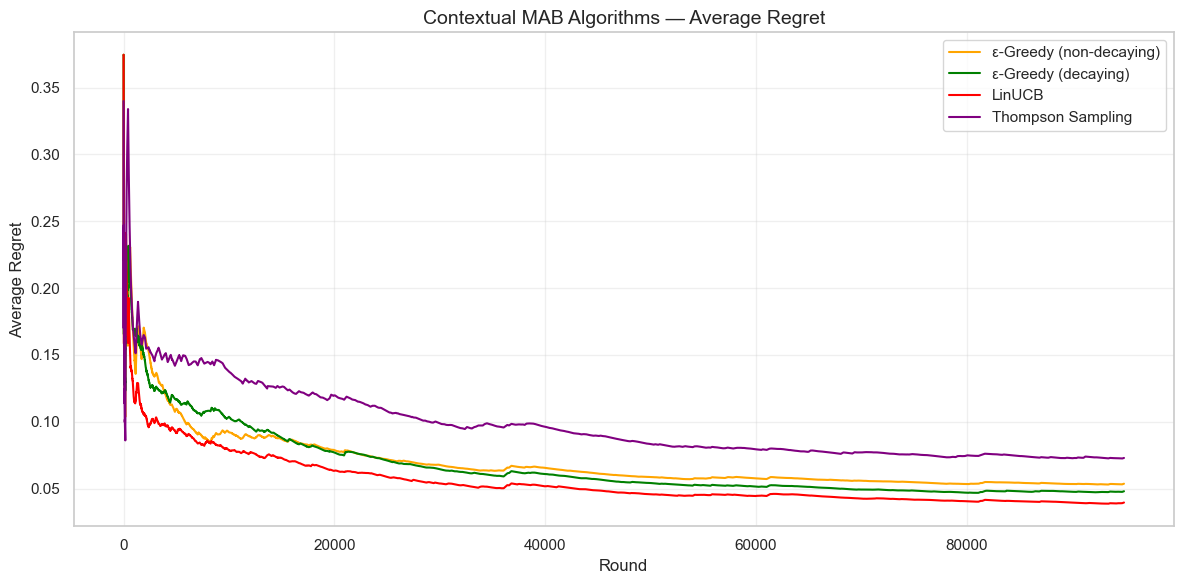

In [194]:

# ── Cumulative Regret Plot ──────────────────────────────────────────────────
colors = {
    'ε-Greedy (non-decaying)': 'orange',
    'ε-Greedy (decaying)': 'green',
    'LinUCB':             'red',
    'Thompson Sampling':  'purple',
}

rounds = range(n_rounds)

fig, ax = plt.subplots(figsize=(12, 6))

# ax.plot(rounds, baseline_regret_cumulative, label='Baseline (Logging Policy)',
#         color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

for name, cum_reg in cumulative_regret.items():
    avg_regret = cum_reg / np.arange(1, len(cum_reg) + 1)

    ax.plot(rounds, avg_regret, label=name, color=colors[name], linewidth=1.5)

ax.set_xlabel('Round', fontsize=12)
ax.set_ylabel('Average Regret', fontsize=12)
ax.set_title('Contextual MAB Algorithms — Average Regret', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

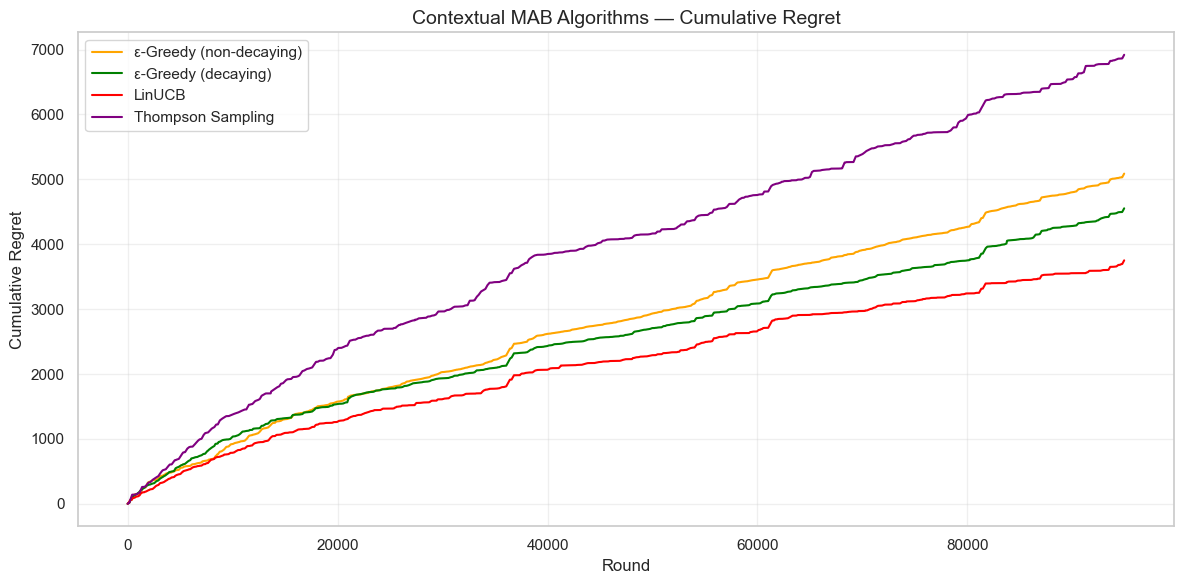

In [195]:
# ── Cumulative Regret Plot ──────────────────────────────────────────────────
colors = {
    'ε-Greedy (non-decaying)': 'orange',
    'ε-Greedy (decaying)': 'green',
    'LinUCB':             'red',
    'Thompson Sampling':  'purple',
}

rounds = range(n_rounds)

fig, ax = plt.subplots(figsize=(12, 6))

# ax.plot(rounds, baseline_regret_cumulative, label='Baseline (Logging Policy)',
#         color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

for name, cum_reg in cumulative_regret.items():
    ax.plot(rounds, cum_reg, label=name, color=colors[name], linewidth=1.5)

ax.set_xlabel('Round', fontsize=12)
ax.set_ylabel('Cumulative Regret', fontsize=12)
ax.set_title('Contextual MAB Algorithms — Cumulative Regret', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

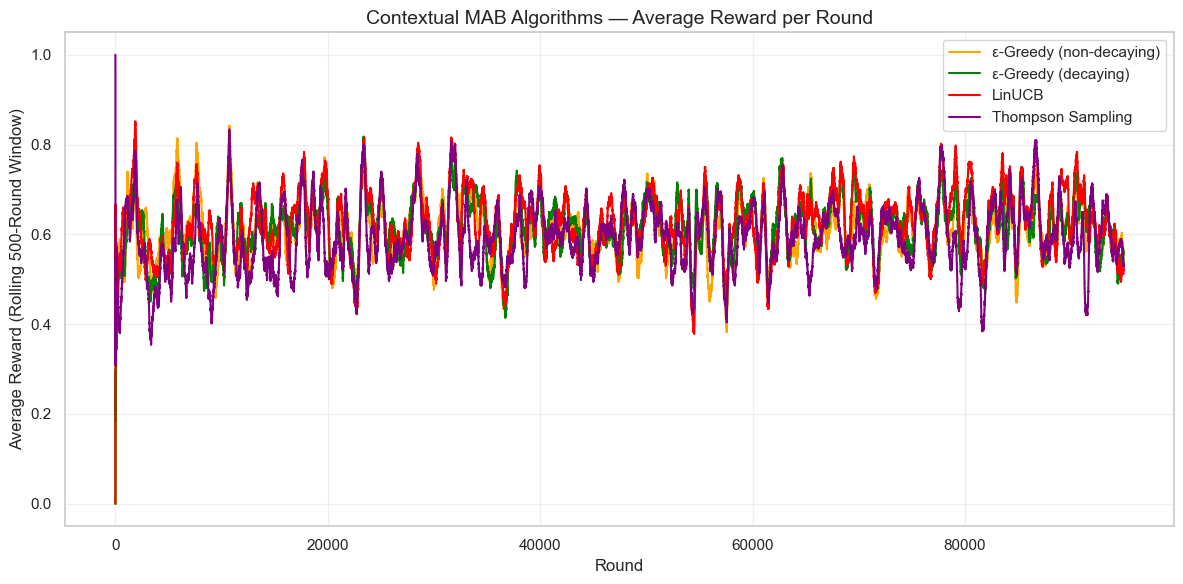


Arm                      ε-Greedy (non-decaying)         ε-Greedy (decaying)                      LinUCB           Thompson Sampling
------------------------------------------------------------------------------------------------------------------------------------
autos                             0.5717 ( 5564 pulls)              0.5339 ( 3609 pulls)              0.5520 ( 5393 pulls)              0.4446 ( 1941 pulls)
entertainment                     0.4409 ( 1016 pulls)              0.4815 (  594 pulls)              0.6421 ( 4255 pulls)              0.6459 ( 3366 pulls)
finance                           0.5918 ( 3008 pulls)              0.3850 (  413 pulls)              0.6029 ( 3850 pulls)              0.0000 (    4 pulls)
foodanddrink                      0.6066 ( 3721 pulls)              0.5659 (  698 pulls)              0.6278 ( 3794 pulls)              0.6424 ( 4267 pulls)
health                            0.6268 (14932 pulls)              0.6099 (17199 pulls)              0.6

In [196]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Average Reward per Round (Rolling Mean) ──────────────────────────────
rolling_window = 500

fig, ax = plt.subplots(figsize=(12, 6))

for name, cum_rewards in cumulative_rewards.items():
    per_round = np.diff([0] + cum_rewards)
    rolling_avg = pd.Series(per_round).rolling(rolling_window, min_periods=1).mean()
    ax.plot(range(n_rounds), rolling_avg, label=name, color=colors[name], linewidth=1.5)

ax.set_xlabel('Round', fontsize=12)
ax.set_ylabel(f'Average Reward (Rolling {rolling_window}-Round Window)', fontsize=12)
ax.set_title('Contextual MAB Algorithms — Average Reward per Round', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── 2. Total CTR per Arm per Algorithm ──────────────────────────────────────
print(f"\n{'Arm':<20}", end="")
for name in algos:
    print(f"{name:>28}", end="")
print()
print("-" * (20 + 28 * len(algos)))

for a, arm in enumerate(arms):
    print(f"{arm:<20}", end="")
    for name, algo in algos.items():
        pulls = int(algo.counts[a])
        rewards_for_arm = algo.rewards[a]
        ctr = rewards_for_arm / pulls if pulls > 0 else 0.0
        print(f"{ctr:>20.4f} ({pulls:>5} pulls)", end="")
    print()

# ── Overall CTR per Algorithm ────────────────────────────────────────────────
print(f"\n{'OVERALL CTR':<20}", end="")
for name, algo in algos.items():
    total_pulls = int(np.sum(algo.counts))
    total_rewards = np.sum(algo.rewards)
    overall_ctr = total_rewards / total_pulls if total_pulls > 0 else 0.0
    print(f"{overall_ctr:>20.4f} ({total_pulls:>5} pulls)", end="")
print()

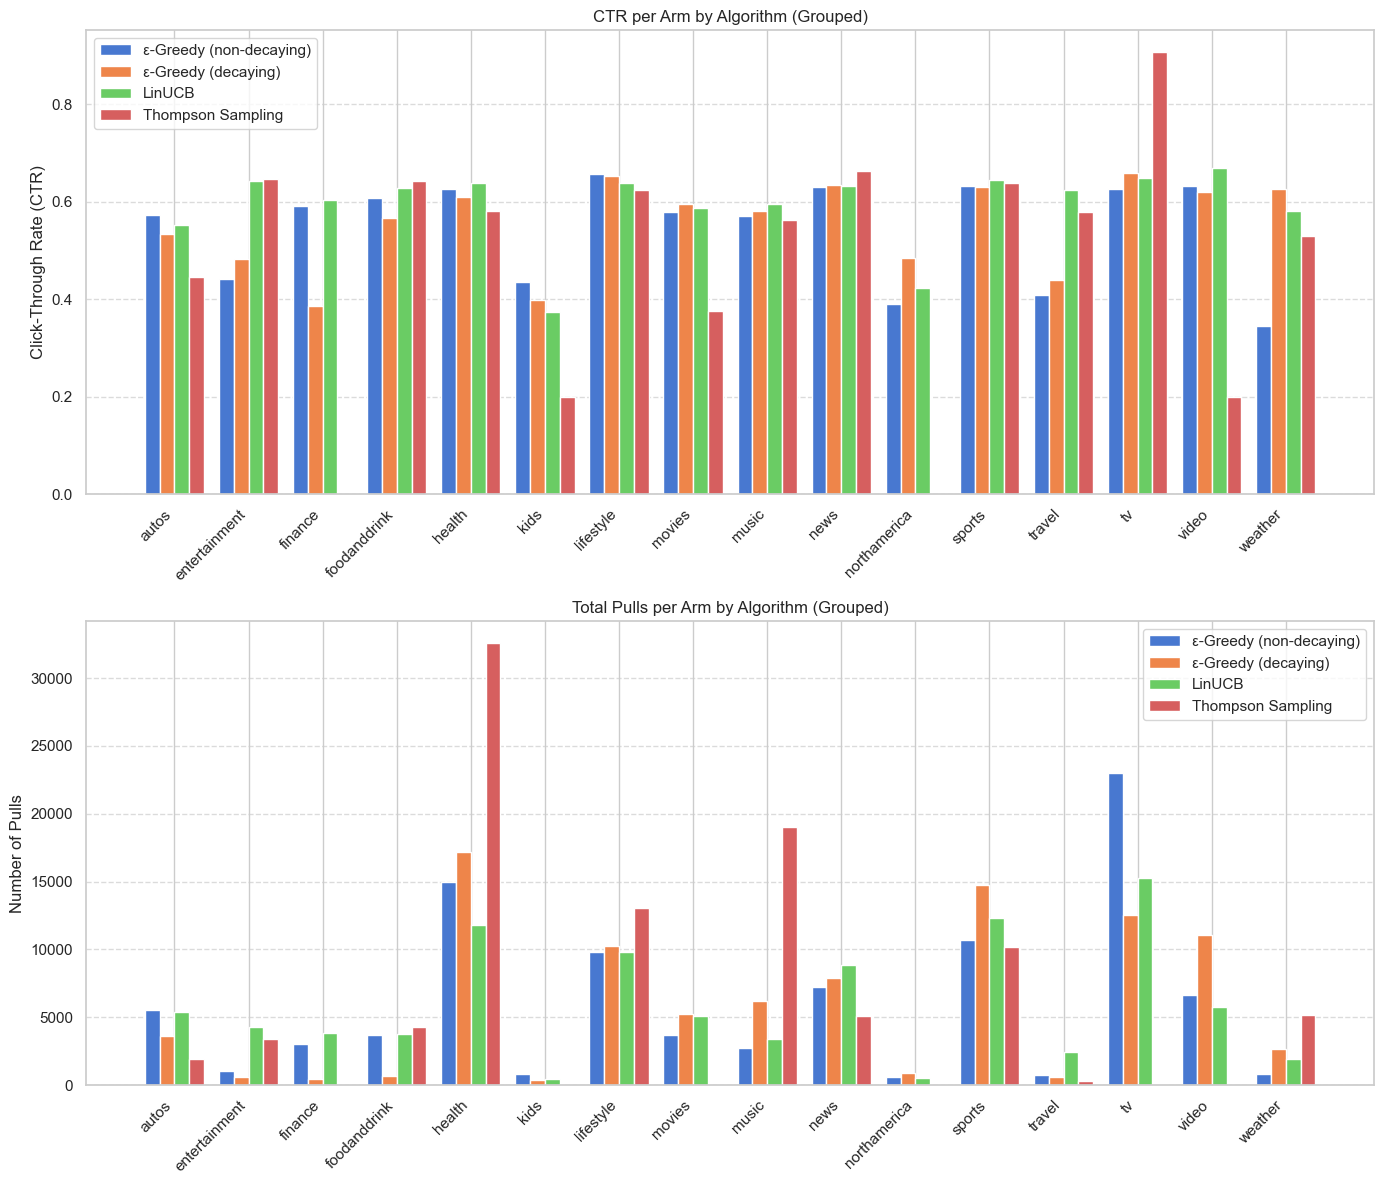

In [197]:
import matplotlib.pyplot as plt
import numpy as np

# Set up the figure and axes (2 subplots: one above the other)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

x = np.arange(len(arms))  # Base x-coordinates for the arms
num_algos = len(algos)
width = 0.8 / num_algos   # Calculate bar width based on number of algorithms

for i, (name, algo) in enumerate(algos.items()):
    # Calculate the offset to place bars side-by-side
    offset = width * i - (0.8 / 2) + (width / 2)

    ctrs = []
    pulls_list = []
    for a in range(len(arms)):
        pulls = int(algo.counts[a])
        # Calculate CTR safely to avoid division by zero
        ctr = algo.rewards[a] / pulls if pulls > 0 else 0.0

        ctrs.append(ctr)
        pulls_list.append(pulls)

    # Plot Grouped CTR (Top Chart)
    ax1.bar(x + offset, ctrs, width, label=name)

    # Plot Grouped Pulls (Bottom Chart)
    ax2.bar(x + offset, pulls_list, width, label=name)

# ==========================================
# Formatting Top Chart (CTR)
# ==========================================
ax1.set_ylabel('Click-Through Rate (CTR)')
ax1.set_title('CTR per Arm by Algorithm (Grouped)')
ax1.set_xticks(x)
ax1.set_xticklabels(arms, rotation=45, ha="right")
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# ==========================================
# Formatting Bottom Chart (Pulls)
# ==========================================
ax2.set_ylabel('Number of Pulls')
ax2.set_title('Total Pulls per Arm by Algorithm (Grouped)')
ax2.set_xticks(x)
ax2.set_xticklabels(arms, rotation=45, ha="right")
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout and display
plt.tight_layout()
plt.show()